<a href="https://colab.research.google.com/github/singhys0404/AAI2025/blob/2026fall/Module_3_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 Machine Learning Coding Assignment

This notebook completes house-price prediction, customer-churn prediction, and customer segmentation, followed by the optional housing-demand forecast.

**Run:** upload this `.ipynb` to Google Colab, choose a Python 3 CPU runtime, and select **Runtime → Run all**. Download and unzip [Module_3_Datasets.zip](https://drive.google.com/file/d/1n8V0i78w9EinG_eTZvjEv9Mb69i7j6Ub/view?usp=drivesdk) first. When prompted, select all four CSV files together. No Kaggle login or Drive mounting is needed. The first run may install a missing library. After running, all plots and explanations appear below, and generated files are in `module3_work/outputs`.

Run cells from the top with **Runtime → Run all**. Running a later results cell alone in a new session can produce a “name is not defined” error because earlier setup/model cells have not run.


## Sources and changes to the starters

| Part | Source and records | Meaningful changes |
|---|---|---|
| 1 | [King County house sales](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction), 21,613 sales | CSV loading, property-group split, explained reference categories, held-out errors, actual ZIP comparison |
| 2 | [IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d/tree/master/data), 7,043 customers | Real account/service columns, missing-value handling, stratified split, corrected coefficient names, precision/recall/AUC |
| 3 | [Cardoso, Wholesale customers, UCI](https://doi.org/10.24432/C5030X), 440 customers; CC BY 4.0 | Actual product spending, log transform, scaling, reproducible elbow choice, silhouette comparison, business strategies |
| Extra | [Census/HUD housing sales via FRED, HSN1F](https://fred.stlouisfed.org/series/HSN1F), 199 months | Real dates and units, lagged regression, chronological six-month backtest, baseline comparison, future forecast |

All source files were retrieved on September 8, 2026. Exact URLs, row counts, and file checksums are retained in `sources.json` in the accompanying dataset ZIP. The housing labels Downtown/Rural/Suburb are simulated; the original prices, square footage, and ZIP codes are retained. Customer datasets use their available fields rather than inventing missing age, usage, or frequency columns.

Starter attribution: [myrah/AAI2025, dev/ML](https://github.com/myrah/AAI2025/tree/dev/ML), specifically `house_price_prediction.py`, `customer_churn_prediction.py`, `customer_segmentation.py`, and `forecasting_sales.py`.


## Setup
This cell checks the libraries and prepares a writable output folder. A GPU is unnecessary.

In [7]:
from pathlib import Path
import os
import sys
import tempfile
import importlib.metadata as metadata
import subprocess

requirements = {"numpy": ((1, 26), "numpy>=1.26,<3"),
                "pandas": ((2, 2), "pandas>=2.2,<3"),
                "scikit-learn": ((1, 4), "scikit-learn>=1.4,<2"),
                "matplotlib": ((3, 8), "matplotlib>=3.8,<4")}
missing = []
for package, (minimum, requirement) in requirements.items():
    try:
        version = tuple(int(x) for x in metadata.version(package).split(".")[:2])
        if version < minimum:
            missing.append(requirement)
    except metadata.PackageNotFoundError:
        missing.append(requirement)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "module3_matplotlib"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
WORK = Path.cwd() / "module3_work"
DATA, OUT = Path.cwd(), WORK / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
print("Python:", sys.version.split()[0])
for package in requirements:
    print(package, metadata.version(package))
print("Output folder:", OUT)


Python: 3.13.15
numpy 2.1.3
pandas 2.2.3
scikit-learn 1.6.1
matplotlib 3.10.0
Output folder: /content/module3_work/outputs


### Upload the four CSV files
Download and unzip **[Module_3_Datasets.zip](https://drive.google.com/file/d/1n8V0i78w9EinG_eTZvjEv9Mb69i7j6Ub/view?usp=drivesdk)**, then run this cell and select the four CSV files together. Keep their original names. The upload dialog is skipped if they are already present. Each model below loads its CSV using `pd.read_csv(...)`.

In a local Jupyter session, place the four CSVs beside the notebook before running it. In Colab, files must be uploaded again after the runtime is reset.


In [8]:
# Upload the datasets once per Colab session.
required_files = ["kc_house_data.csv", "telco_churn.csv",
                  "Wholesale customers data.csv", "housing_demand.csv"]

if not all((DATA / name).exists() for name in required_files):
    from google.colab import files
    files.upload()  # Select all four CSV files together.

for name in required_files:
    if not (DATA / name).exists():
        raise FileNotFoundError(f"Please upload {name} and run this cell again.")
    print(f"{name}: {len(pd.read_csv(DATA / name)):,} records")


Saving housing_demand.csv to housing_demand.csv
Saving kc_house_data.csv to kc_house_data.csv
Saving sources.json to sources.json
Saving telco_churn.csv to telco_churn.csv
Saving Wholesale customers data.csv to Wholesale customers data.csv
kc_house_data.csv: 21,613 records
telco_churn.csv: 7,043 records
Wholesale customers data.csv: 440 records
housing_demand.csv: 199 records


## Part 1 House Price Prediction

Linear regression estimates price from size and encoded location. The required example predicts a 2,000 sq ft house in Downtown. Because the source uses ZIP codes, the simulated labels are clearly separated from a second model using real ZIP codes. Repeated sales of one property stay together in the train/test split. The printed explanations distinguish associations from causal effects and interpret every demo coefficient.

In [9]:
"""Part 1: linear regression using real prices, living area, and location."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # Save figures reliably in scripts, notebooks, and headless runs.
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def run_house(data_dir=Path("data"), output_dir=Path("outputs")):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    # Source: King County house sales, May 2014-May 2015, downloaded 2026-09-08.
    # https://www.kaggle.com/datasets/harlfoxem/housesalesprediction
    # sqft_living is living area in square feet; price is sale price in USD.
    raw = pd.read_csv(Path(data_dir) / "kc_house_data.csv", dtype={"id": str, "zipcode": str})
    df = raw[["id", "sqft_living", "zipcode", "price"]].rename(
        columns={"sqft_living": "square_footage"}).copy()
    for col in ["square_footage", "price"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    df = df[(df.square_footage > 0) & (df.price > 0)].reset_index(drop=True)
    assert len(df) >= 100

    # labels. These labels are SIMULATED, not actual King County neighborhoods.
    # Assign once per property, without using price, so repeat sales keep a label.
    ids = sorted(df.id.unique())
    rng = np.random.default_rng(42)
    locations = dict(zip(ids, rng.choice(["Downtown", "Rural", "Suburb"], len(ids))))
    df["location"] = df.id.map(locations)
    df.to_csv(output_dir / "housing_prepared.csv", index=False)

    # A property may sell more than once. Keep its sales on the same side of the
    # split to avoid evaluating on a property already seen during training.
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(df, groups=df.id))
    assert set(df.iloc[train_idx].id).isdisjoint(df.iloc[test_idx].id)
    y_train, y_test = df.iloc[train_idx].price, df.iloc[test_idx].price

    def fit_location_model(location_column):
        features = ["square_footage", location_column]
        prep = ColumnTransformer([
            ("location", OneHotEncoder(drop="first", sparse_output=False), [location_column]),
            ("numeric", "passthrough", ["square_footage"]),
        ])
        model = Pipeline([("preprocessor", prep), ("regressor", LinearRegression())])
        model.fit(df.iloc[train_idx][features], y_train)
        pred = model.predict(df.iloc[test_idx][features])
        metrics = {"MAE_USD": float(mean_absolute_error(y_test, pred)),
                   "RMSE_USD": float(np.sqrt(mean_squared_error(y_test, pred))),
                   "R2": float(r2_score(y_test, pred))}
        # Obtain names from the fitted transformer, in the exact model order.
        coefficients = pd.DataFrame({
            "feature": model.named_steps["preprocessor"].get_feature_names_out(),
            "coefficient": model.named_steps["regressor"].coef_})
        return model, pred, metrics, coefficients

    demo, demo_pred, demo_metrics, demo_coef = fit_location_model("location")
    real, real_pred, real_metrics, real_coef = fit_location_model("zipcode")
    new_house = pd.DataFrame({"square_footage": [2000], "location": ["Downtown"]})
    predicted_price = float(demo.predict(new_house)[0])
    baseline = DummyRegressor(strategy="mean").fit(np.zeros((len(y_train), 1)), y_train)
    baseline_mae = float(mean_absolute_error(y_test, baseline.predict(np.zeros((len(y_test), 1)))))
    demo_coef.to_csv(output_dir / "house_demo_coefficients.csv", index=False)
    real_coef.to_csv(output_dir / "house_zipcode_coefficients.csv", index=False)
    pd.DataFrame({"actual_price": y_test.to_numpy(), "demo_prediction": demo_pred,
                  "zipcode_prediction": real_pred}).to_csv(output_dir / "house_test_predictions.csv", index=False)

    slope = float(demo_coef.loc[demo_coef.feature == "numeric__square_footage", "coefficient"].iloc[0])
    intercept = float(demo.named_steps["regressor"].intercept_)
    explanation = [
        f"Part 1 uses {len(df):,} valid sales ({len(train_idx):,} train; {len(test_idx):,} test).",
        f"Required example: a 2,000 sq ft house labeled Downtown is predicted at ${predicted_price:,.2f}.",
        f"The fitted square-footage coefficient is ${slope:,.2f}: holding the simulated location fixed, "
        "one additional square foot changes predicted price by that amount. This is an association, not a causal effect.",
        f"The intercept is ${intercept:,.2f}. It is the equation's baseline at zero square feet, "
        "which is outside a sensible house-size range and has no useful standalone valuation meaning.",
        "Downtown is the reference category. Its location offset is zero; the other offsets below "
        "are relative to Downtown at the same square footage.",
    ]
    for row in demo_coef.itertuples():
        if row.feature.startswith("location__"):
            explanation.append(f"{row.feature.removeprefix('location__location_')}: ${row.coefficient:+,.2f} relative to Downtown.")
    explanation += [
        "The three location labels were randomly generated as permitted in the checklist. Their coefficients "
        "reflect chance differences and do not establish real Downtown/Suburb/Rural price effects.",
        f"Held-out demo MAE: ${demo_metrics['MAE_USD']:,.0f}; R²: {demo_metrics['R2']:.3f}.",
        f"Improvement using actual ZIP codes: MAE ${real_metrics['MAE_USD']:,.0f}; R² {real_metrics['R2']:.3f}. "
        f"The training-mean baseline MAE is ${baseline_mae:,.0f}.",
        "The ZIP-code model uses the first sorted training ZIP code as its reference. Its saved coefficients "
        "are price offsets at fixed size. Even real ZIP effects are associations and may reflect omitted house quality.",
        "Limitations: these are historical local sales, only size/location are modeled, and high-price outliers "
        "remain. Future work could add age, condition, and bedrooms and use a chronological validation split.",
    ]
    print("\n".join(explanation))
    print("\nRequired model coefficients:\n", demo_coef.to_string(index=False))
    (output_dir / "part1_explanation.txt").write_text("\n\n".join(explanation))
    metrics = {"rows": len(df), "train_rows": len(train_idx), "test_rows": len(test_idx),
               "demo": demo_metrics, "actual_zipcode": real_metrics, "baseline_MAE_USD": baseline_mae,
               "downtown_2000_sqft_prediction": predicted_price, "square_footage_coefficient": slope}
    (output_dir / "house_metrics.json").write_text(json.dumps(metrics, indent=2))
    fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
    ax.scatter(y_test / 1e6, real_pred / 1e6, alpha=0.35, s=10)
    limit = max(y_test.max(), real_pred.max()) / 1e6
    ax.plot([0, limit], [0, limit], "k--", label="Perfect prediction")
    ax.set(xlabel="Actual sale price (million USD)", ylabel="Predicted price (million USD)",
           title="House prices: held-out sales using actual ZIP codes")
    ax.legend()
    fig.savefig(output_dir / "house_predictions.png", dpi=150)
    plt.close(fig)
    return metrics

Part 1 uses 21,613 valid sales (17,289 train; 4,324 test).
Required example: a 2,000 sq ft house labeled Downtown is predicted at $515,072.58.
The fitted square-footage coefficient is $280.01: holding the simulated location fixed, one additional square foot changes predicted price by that amount. This is an association, not a causal effect.
The intercept is $-44,951.81. It is the equation's baseline at zero square feet, which is outside a sensible house-size range and has no useful standalone valuation meaning.
Downtown is the reference category. Its location offset is zero; the other offsets below are relative to Downtown at the same square footage.
Rural: $+6,607.99 relative to Downtown.
Suburb: $-930.64 relative to Downtown.
The three location labels were randomly generated as permitted in the checklist. Their coefficients reflect chance differences and do not establish real Downtown/Suburb/Rural price effects.
Held-out demo MAE: $176,112; R²: 0.497.
Improvement using actual ZIP cod

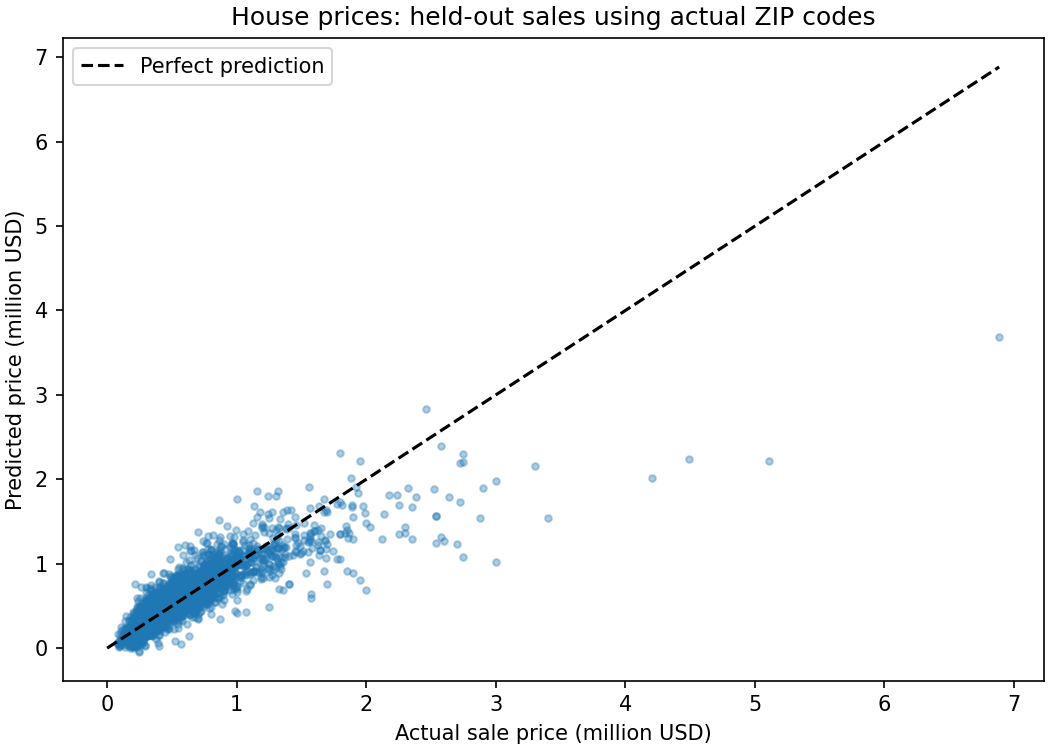

In [10]:
house_results = run_house(DATA, OUT)
display(Image(filename=str(OUT / "house_predictions.png")))

## Part 2 Customer Churn Prediction

Logistic regression estimates churn probability from actual customer account and service fields. Numerical imputation/scaling and categorical encoding are fitted only on the training set. A stratified test set checks performance. Probabilities at least 0.5 are classified as at risk; the example, threshold interpretation, coefficient meanings, and retention use are explained in the output.

In [11]:
"""Part 2: predict churn probability with logistic regression."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # Save figures reliably in scripts, notebooks, and headless runs.
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, brier_score_loss, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder


def run_churn(data_dir=Path("data"), output_dir=Path("outputs")):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    # Source: IBM Telco Customer Churn educational dataset, retrieved 2026-09-08.
    # https://github.com/IBM/telco-customer-churn-on-icp4d/tree/master/data
    # Also listed at https://www.kaggle.com/datasets/blastchar/telco-customer-churn
    # Use the dataset's actual account/service fields; do not invent age/usage/calls.
    df = pd.read_csv(Path(data_dir) / "telco_churn.csv")
    assert df.customerID.is_unique, "Customer IDs must be unique before splitting."
    assert set(df.Churn.unique()) == {"Yes", "No"}
    numeric = ["tenure", "MonthlyCharges", "TotalCharges"]
    categorical = ["SeniorCitizen", "Partner", "Dependents", "InternetService",
                   "TechSupport", "Contract", "PaperlessBilling", "PaymentMethod"]
    for col in numeric:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df[numeric] = df[numeric].replace([np.inf, -np.inf], np.nan)
    missing_total = int(df.TotalCharges.isna().sum())
    df[categorical] = df[categorical].astype(str)
    X, y = df[numeric + categorical], df.Churn.map({"No": 0, "Yes": 1})
    assert len(df) >= 100
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)
    # Learn imputation, scaling, and encoding from training data only.
    prep = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), numeric),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical),
    ])
    model = Pipeline([("preprocessor", prep),
                      ("classifier", LogisticRegression(max_iter=2000, random_state=42))])
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_test)[:, 1]
    threshold = 0.5
    prediction = (probability >= threshold).astype(int)
    metrics = {"rows": len(df), "train_rows": len(X_train), "test_rows": len(X_test),
               "missing_total_charges": missing_total,
               "accuracy": float(accuracy_score(y_test, prediction)),
               "precision": float(precision_score(y_test, prediction, zero_division=0)),
               "recall": float(recall_score(y_test, prediction, zero_division=0)),
               "f1": float(f1_score(y_test, prediction, zero_division=0)),
               "roc_auc": float(roc_auc_score(y_test, probability)),
               "brier_score": float(brier_score_loss(y_test, probability)),
               "majority_baseline_accuracy": float(accuracy_score(y_test, np.zeros(len(y_test)))),
               "threshold": threshold}
    new_customer = pd.DataFrame([{
        "tenure": 6, "MonthlyCharges": 85.0, "TotalCharges": 510.0,
        "SeniorCitizen": "0", "Partner": "No", "Dependents": "No",
        "InternetService": "Fiber optic", "TechSupport": "No", "Contract": "Month-to-month",
        "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    }])
    new_probability = float(model.predict_proba(new_customer)[0, 1])
    new_prediction = int(new_probability >= threshold)
    metrics.update(new_customer_probability=new_probability, new_customer_class=new_prediction)
    coefficients = pd.DataFrame({
        "feature": model.named_steps["preprocessor"].get_feature_names_out(),
        "log_odds_coefficient": model.named_steps["classifier"].coef_[0]})
    coefficients["odds_ratio"] = np.exp(coefficients.log_odds_coefficient)
    coefficients.to_csv(output_dir / "churn_coefficients.csv", index=False)
    pd.DataFrame({"customerID": df.loc[X_test.index, "customerID"], "actual_churn": y_test,
                  "churn_probability": probability, "predicted_churn": prediction}).to_csv(
        output_dir / "churn_test_predictions.csv", index=False)
    explanation = [
        f"Part 2 uses {len(df):,} customers ({len(X_train):,} train; {len(X_test):,} test). "
        f"The {missing_total} blank/non-numeric TotalCharges values are imputed with the training median.",
        f"The example customer has a predicted churn probability of {new_probability:.3f} "
        f"({new_probability:.1%}) and class {new_prediction}, using probability >= 0.5 as at risk.",
        "This is a model-estimated likelihood of the dataset's churn outcome, not a certainty or a "
        "validated guarantee for a new population. The example uses a short-tenure, month-to-month account.",
        f"Held-out accuracy {metrics['accuracy']:.3f}, precision {metrics['precision']:.3f}, "
        f"recall {metrics['recall']:.3f}, F1 {metrics['f1']:.3f}, ROC AUC {metrics['roc_auc']:.3f}. "
        f"Always predicting no churn gives accuracy {metrics['majority_baseline_accuracy']:.3f}.",
        "Precision describes how many flagged customers actually churned; recall describes how many "
        "churners were found. Accuracy alone can hide missed churners because non-churners are the majority.",
        "Coefficient names come from the fitted preprocessing pipeline, fixing the starter's name/order mismatch. "
        "A positive coefficient increases log-odds of churn, holding other features fixed; a negative one decreases them. "
        "Numeric coefficients correspond to a one-training-standard-deviation increase, not one raw unit. "
        "Categorical coefficients compare with the dropped reference category; odds ratios are exp(coefficient), "
        "not percentage-point probability changes.",
        "Businesses can prioritize flagged accounts for service check-ins, resolve support issues, and test relevant "
        "retention offers. Test interventions with controlled experiments; these associations do not prove an offer prevents churn.",
        "Limitations and improvements: this is a public educational dataset. Validate on later real customer cohorts, "
        "check probability calibration, and choose a threshold using validation data and the costs of missed churn versus unnecessary offers.",
    ]
    encoder = model.named_steps["preprocessor"].named_transformers_["cat"]
    explanation.append("Categorical reference values: " + "; ".join(
        f"{col}={cats[0]}" for col, cats in zip(categorical, encoder.categories_)) + ".")
    print("\n".join(explanation))
    print("\nModel coefficients:\n", coefficients.to_string(index=False))
    (output_dir / "part2_explanation.txt").write_text("\n\n".join(explanation))
    (output_dir / "churn_metrics.json").write_text(json.dumps(metrics, indent=2))
    fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
    ConfusionMatrixDisplay.from_predictions(y_test, prediction, display_labels=["No churn", "Churn"],
                                           colorbar=False, ax=ax, cmap="Blues")
    ax.set_title("Customer churn: held-out results at threshold 0.5")
    fig.savefig(output_dir / "churn_confusion_matrix.png", dpi=150)
    plt.close(fig)
    return metrics

Part 2 uses 7,043 customers (5,634 train; 1,409 test). The 11 blank/non-numeric TotalCharges values are imputed with the training median.
The example customer has a predicted churn probability of 0.721 (72.1%) and class 1, using probability >= 0.5 as at risk.
This is a model-estimated likelihood of the dataset's churn outcome, not a certainty or a validated guarantee for a new population. The example uses a short-tenure, month-to-month account.
Held-out accuracy 0.796, precision 0.638, recall 0.537, F1 0.583, ROC AUC 0.838. Always predicting no churn gives accuracy 0.735.
Precision describes how many flagged customers actually churned; recall describes how many churners were found. Accuracy alone can hide missed churners because non-churners are the majority.
Coefficient names come from the fitted preprocessing pipeline, fixing the starter's name/order mismatch. A positive coefficient increases log-odds of churn, holding other features fixed; a negative one decreases them. Numeric coef

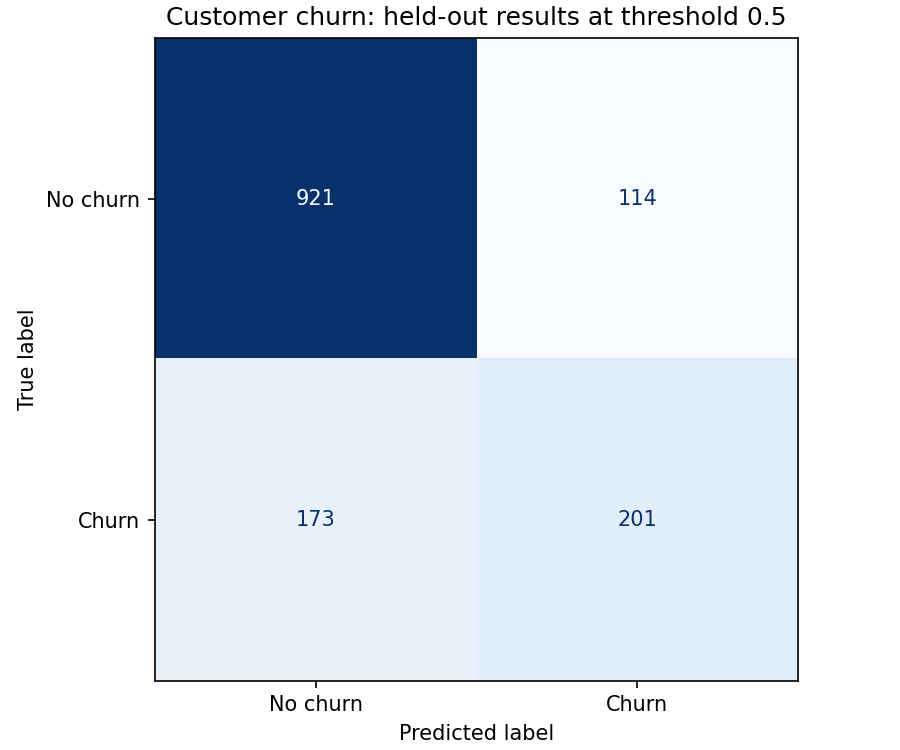

In [12]:
churn_results = run_churn(DATA, OUT)
display(Image(filename=str(OUT / "churn_confusion_matrix.png")))

## Part 3 Customer Segmentation

K-Means groups customers by six annual product-spending categories. Log transformation and StandardScaler reduce the dominance of skewed, high-value categories. The elbow heuristic chooses K from 1–8 rather than assuming 3. Silhouette scores help assess overlap. Cluster means are reported in original monetary units and used to propose marketing strategies. Every assignment is saved to `customer_segments.csv`.

In [13]:
"""Part 3: segment wholesale customers by annual purchasing patterns."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # Save figures reliably in scripts, notebooks, and headless runs.
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


def run_segments(data_dir=Path("data"), output_dir=Path("outputs")):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    # Source: Cardoso, M. (2013). Wholesale customers. UCI ML Repository.
    # https://archive.ics.uci.edu/dataset/292/wholesale+customers
    # DOI https://doi.org/10.24432/C5030X ; CC BY 4.0; retrieved 2026-09-08.
    # Features are annual spending in monetary units, not dollars. The source
    # has no age or purchase-frequency fields; use actual category spending.
    df = pd.read_csv(Path(data_dir) / "Wholesale customers data.csv")
    features = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
    df[features] = df[features].apply(pd.to_numeric, errors="coerce")
    assert len(df) >= 100 and np.isfinite(df[features]).all().all()
    assert (df[features] >= 0).all().all()
    df.insert(0, "customer_row_id", np.arange(1, len(df) + 1))
    # Strongly skewed spending would otherwise let a few large customers dominate.
    # log1p handles zero values; StandardScaler then gives categories equal scale.
    scaled = StandardScaler().fit_transform(np.log1p(df[features]))
    k_values = np.arange(1, 9)
    models = [KMeans(n_clusters=int(k), n_init=20, random_state=42).fit(scaled) for k in k_values]
    inertia = np.array([m.inertia_ for m in models])
    # Reproducible elbow heuristic: largest distance below the normalized line
    # joining the first and last inertia points. This is a heuristic, not proof
    # of a unique optimal K. Silhouette scores provide a second view.
    x_norm = (k_values - k_values.min()) / (k_values.max() - k_values.min())
    y_norm = (inertia - inertia[-1]) / (inertia[0] - inertia[-1])
    elbow_distance = (1 - x_norm) - y_norm
    selected_k = int(k_values[np.argmax(elbow_distance)])
    assert 2 <= selected_k <= 7
    scores = [np.nan] + [silhouette_score(scaled, m.labels_) for m in models[1:]]
    diagnostics = pd.DataFrame({"K": k_values, "inertia": inertia,
                                "elbow_distance": elbow_distance, "silhouette": scores})
    diagnostics.to_csv(output_dir / "cluster_diagnostics.csv", index=False)
    labels = models[selected_k - 1].labels_
    # Re-label by mean total spending, so labels run from lower to higher spend.
    df["annual_spending"] = df[features].sum(axis=1)
    df["cluster"] = labels
    order = df.groupby("cluster").annual_spending.mean().sort_values().index
    df["cluster"] = df.cluster.map({old: new for new, old in enumerate(order)})
    summary = df.groupby("cluster")[features + ["annual_spending"]].mean()
    summary.insert(0, "customers", df.groupby("cluster").size())
    summary["median_annual_spending"] = df.groupby("cluster").annual_spending.median()
    summary.to_csv(output_dir / "cluster_summary.csv")
    df.to_csv(output_dir / "customer_segments.csv", index=False)

    explanations = [
        f"Part 3 uses {len(df)} wholesale customers and six annual spending categories.",
        "Age and purchase frequency are unavailable, so no claims about those characteristics are made. "
        "Channel and Region are retained for context but not treated as numerical distances in clustering.",
        f"Selected K={selected_k}: it has the largest normalized distance from the straight line joining "
        "K=1 and K=8 on the elbow curve. The plot shows diminishing reductions in inertia around this candidate.",
        f"Its silhouette score is {scores[selected_k - 1]:.3f}; the highest tested silhouette "
        f"is {max(scores[1:]):.3f} at K={int(k_values[1:][np.argmax(scores[1:])])}. "
        "The elbow choice balances extra segments against diminishing fit gains; silhouette need not select the same K.",
        "Clustering uses log-transformed, standardized spending; the summary below uses original monetary units "
        "so the business interpretation remains understandable. Cluster IDs are arbitrary, reordered here by mean total spending.",
    ]
    median_customer_spend = df.annual_spending.median()
    for cluster, row in summary.iterrows():
        top_categories = row[features].nlargest(2).index.tolist()
        spending_level = "higher" if row.annual_spending >= median_customer_spend else "lower"
        offer = ("Offer account support and volume-based loyalty discounts" if spending_level == "higher"
                 else "Test smaller, affordable bundles and low-minimum-order promotions")
        explanations.append(
            f"Cluster {cluster}: {int(row.customers)} customers; mean annual spending {row.annual_spending:,.0f} "
            f"monetary units (median {row.median_annual_spending:,.0f}), {spending_level} than the overall customer median "
            f"of {median_customer_spend:,.0f}. Its two largest mean spending categories are "
            f"{top_categories[0]} and {top_categories[1]}. {offer} focused on these categories. "
            "Measure response and margin before expanding the campaign.")
    explanations.append(
        "Limitations: a modest historical sample, overlapping segments, and dependence on scaling/K. "
        "Spending is not profit or engagement. Future work could check cluster stability and add transaction recency/frequency if collected.")
    print(diagnostics.round(3).to_string(index=False))
    print("\nCluster means in original monetary units:\n", summary.round(1).to_string())
    print("\n".join(explanations))
    (output_dir / "part3_explanation.txt").write_text("\n\n".join(explanations))
    metrics = {"rows": len(df), "selected_k": selected_k,
               "silhouette": float(scores[selected_k - 1]),
               "cluster_sizes": {str(k): int(v) for k, v in df.groupby("cluster").size().items()}}
    (output_dir / "segmentation_metrics.json").write_text(json.dumps(metrics, indent=2))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
    axes[0].plot(k_values, inertia, "o-", color="#2563eb")
    axes[0].axvline(selected_k, color="#d97706", linestyle="--", label=f"Selected K={selected_k}")
    axes[0].set(xlabel="Number of clusters (K)", ylabel="Inertia", title="Elbow method", xticks=k_values)
    axes[0].legend()
    axes[1].plot(k_values[1:], scores[1:], "o-", color="#0f766e")
    axes[1].set(xlabel="Number of clusters (K)", ylabel="Silhouette score", title="Cluster separation", xticks=k_values[1:])
    fig.savefig(output_dir / "elbow_plot.png", dpi=150)
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
    summary[features].plot.bar(stacked=True, ax=ax, colormap="viridis")
    ax.set(xlabel="Cluster (ordered by mean total spending)", ylabel="Mean annual spending (monetary units)",
           title="Customer segments by purchasing category")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.savefig(output_dir / "cluster_profiles.png", dpi=150)
    plt.close(fig)
    return metrics

 K  inertia  elbow_distance  silhouette
 1 2640.000           0.000         NaN
 2 1844.064           0.350       0.290
 3 1553.413           0.387       0.258
 4 1386.863           0.347       0.188
 5 1266.149           0.279       0.192
 6 1174.536           0.193       0.195
 7 1086.359           0.104       0.196
 8 1024.047           0.000       0.191

Cluster means in original monetary units:
          customers    Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen  annual_spending  median_annual_spending
cluster                                                                                                                     
0              212  11992.6   1995.4   2496.9  3277.8             425.9       892.5          21081.2                 18498.0
1               83   2966.9   7010.9  12397.3   608.3            5446.2       795.0          29224.6                 27251.0
2              145  17182.4  10658.1  13381.0  4181.1            5003.6      2867.2          532

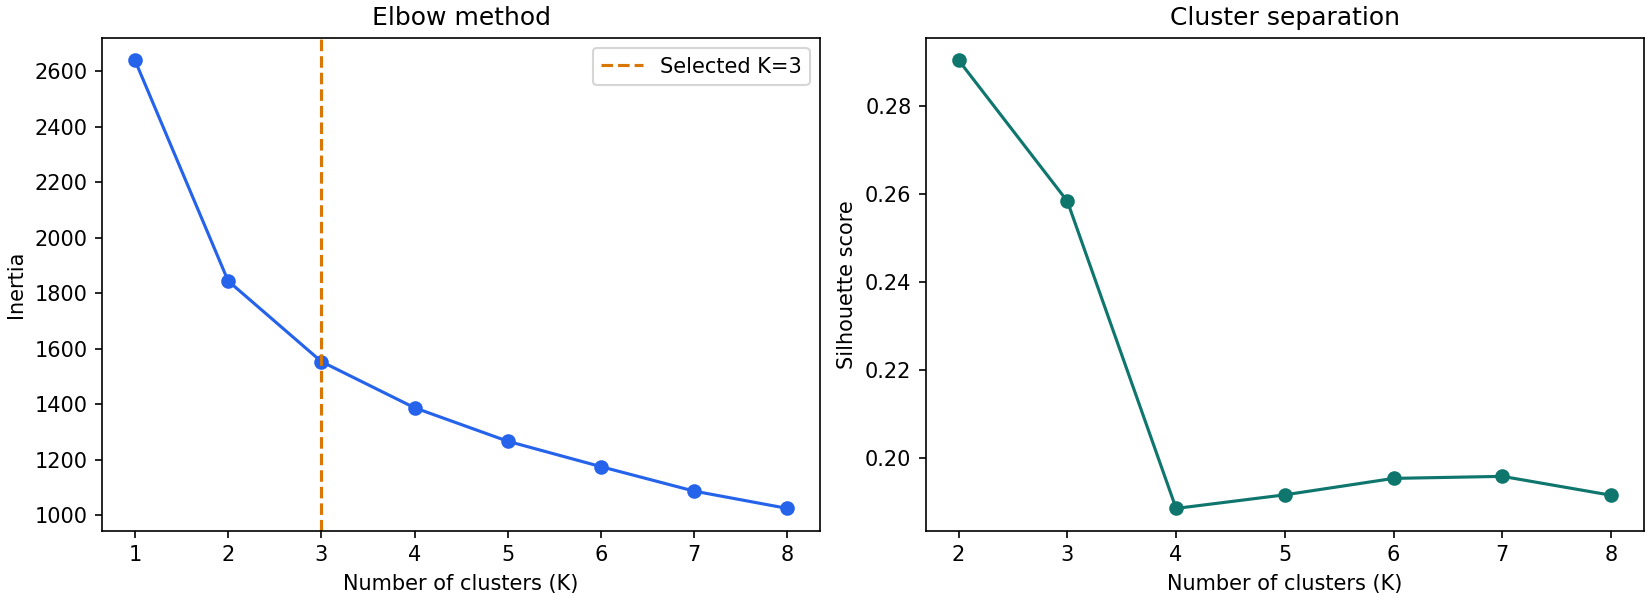

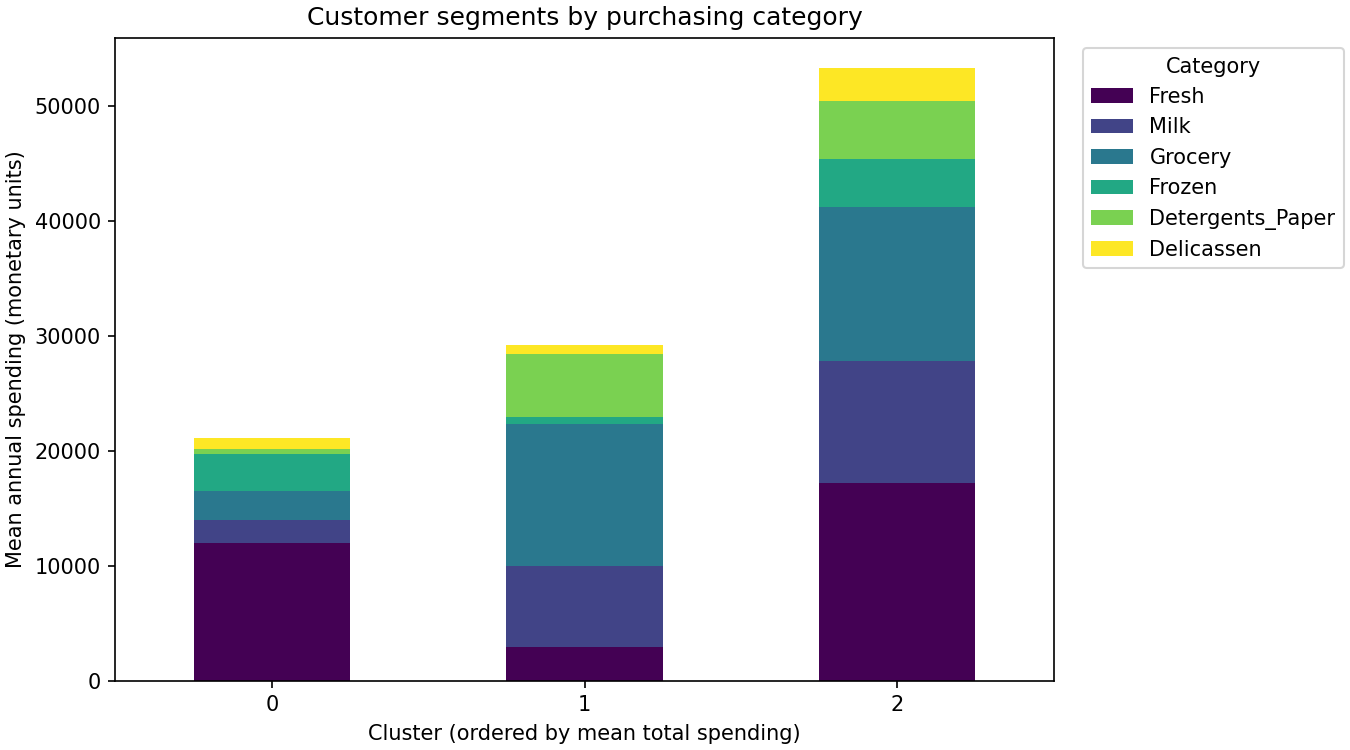

In [14]:
segment_results = run_segments(DATA, OUT)
display(Image(filename=str(OUT / "elbow_plot.png")))
display(Image(filename=str(OUT / "cluster_profiles.png")))

## Extra Credit Six-Month Housing Demand Forecast

The three required parts are complete above. This extension reads documented monthly housing-sales data and uses linear regression on time and lagged sales. A six-month chronological holdout is predicted recursively without feeding actual future sales into the model. The final model is refitted on all history for the next six months. Sales are a proxy for realized housing demand. **Units are thousands of homes at a seasonally adjusted annual rate, not monthly unit counts or house prices.** The supplied 12-row sales example was replaced because its year and units were unspecified.

In [15]:
"""Extra credit: six-month housing-sales forecast with linear regression."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


def run_forecast(data_dir=Path("data"), output_dir=Path("outputs")):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    # Source: U.S. Census Bureau and HUD, New One Family Houses Sold: United
    # States [HSN1F], retrieved from FRED on 2026-09-08.
    # https://fred.stlouisfed.org/series/HSN1F
    # Snapshot: Jan 2010-Jul 2026. Units: thousands, seasonally adjusted annual
    # rate (SAAR). These are monthly observations of an annualized sales rate,
    # NOT actual monthly counts, prices, or revenue. Sales proxy realized demand.
    raw = pd.read_csv(Path(data_dir) / "housing_demand.csv")
    df = raw.rename(columns={"observation_date": "month", "HSN1F": "sales"}).copy()
    df["month"] = pd.to_datetime(df.month, errors="coerce")
    df["sales"] = pd.to_numeric(df.sales, errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna().sort_values("month").reset_index(drop=True)
    assert len(df) >= 100 and df.month.is_unique and (df.sales >= 0).all()
    expected_dates = pd.date_range(df.month.min(), df.month.max(), freq="MS")
    assert df.month.tolist() == expected_dates.tolist(), "Monthly gaps must be resolved before lag creation."
    df.to_csv(output_dir / "housing_demand_cleaned.csv", index=False)

    def fit_history(history):
        # Only past sales are features. Avoid random splits for forecasting.
        training = pd.DataFrame({"sales": np.asarray(history, dtype=float)})
        training["month_index"] = np.arange(len(training))
        training["lag_1"] = training.sales.shift(1)
        training["lag_12"] = training.sales.shift(12)
        training = training.dropna()
        columns = ["month_index", "lag_1", "lag_12"]
        model = LinearRegression().fit(training[columns], training.sales)
        return model

    def predict_six(model, history):
        # Multi-step recursion uses earlier PREDICTIONS after the forecast origin.
        # Actual held-out future values are never fed into the next prediction.
        values = list(np.asarray(history, dtype=float))
        forecast, clipped = [], 0
        for _ in range(6):
            features = pd.DataFrame({"month_index": [len(values)],
                                     "lag_1": [values[-1]], "lag_12": [values[-12]]})
            raw_prediction = float(model.predict(features)[0])
            prediction = max(0.0, raw_prediction)  # Sales rates cannot be negative.
            clipped += int(raw_prediction < 0)
            forecast.append(prediction)
            values.append(prediction)
        return np.array(forecast), clipped

    history, holdout = df.iloc[:-6], df.iloc[-6:]
    backtest_model = fit_history(history.sales)
    backtest_prediction, backtest_clipped = predict_six(backtest_model, history.sales)
    naive = np.repeat(history.sales.iloc[-1], 6)
    model_mae = float(mean_absolute_error(holdout.sales, backtest_prediction))
    naive_mae = float(mean_absolute_error(holdout.sales, naive))
    backtest = pd.DataFrame({"month": holdout.month.to_numpy(), "actual_sales": holdout.sales.to_numpy(),
                             "regression_forecast": backtest_prediction, "last_value_baseline": naive})
    backtest.to_csv(output_dir / "forecast_backtest.csv", index=False)

    final_model = fit_history(df.sales)
    prediction, clipped = predict_six(final_model, df.sales)
    future_months = pd.date_range(df.month.max() + pd.offsets.MonthBegin(1), periods=6, freq="MS")
    forecast = pd.DataFrame({"month": future_months, "forecast_sales_thousands_SAAR": prediction})
    forecast.to_csv(output_dir / "six_month_forecast.csv", index=False)
    comparison = "lower" if model_mae < naive_mae else "higher"
    explanations = [
        f"Extra credit uses {len(df)} monthly housing-sales observations from "
        f"{df.month.min():%B %Y} through {df.month.max():%B %Y}.",
        "The regression uses elapsed month, prior-month sales, and sales twelve months earlier. "
        "The first twelve rows supply lag history, leaving the remaining rows as training targets.",
        f"A chronological six-month backtest gives MAE {model_mae:.2f} and RMSE "
        f"{np.sqrt(mean_squared_error(holdout.sales, backtest_prediction)):.2f}; "
        f"the last-observed-value baseline gives MAE {naive_mae:.2f}. Regression error is {comparison} on this holdout.",
        "This single holdout is a diagnostic, not evidence of reliable future accuracy. "
        "The final regression is refitted using all available history before producing six future predictions.",
        "Units are thousands of homes at a seasonally adjusted annual rate. For example, 600 means "
        "an annualized pace of 600,000 new homes sold, not 600 homes sold in that month. "
        "Completed sales are a proxy for realized demand and also depend on available supply.",
        "Assumptions: recent relationships continue; the time series stays comparable; lagged sales remain "
        "informative. The data is already seasonally adjusted, so no raw monthly seasonality is asserted.",
        "Challenges: interest rates, economic shocks, changing inventory, revisions to historical data, "
        "and errors that accumulate during recursive forecasting. The plot shows point estimates without uncertainty bands.",
        "Potential improvements: rolling-origin backtests, comparison with seasonal-naive and time-series models, "
        "mortgage-rate/inventory predictors, and properly calibrated prediction intervals.",
        f"Negative predictions clipped to zero: {backtest_clipped} in backtesting and {clipped} in the final forecast.",
        "The instructor-provided sales_data.csv is preserved under starter_reference. Its 12 rows have "
        "unspecified sales units and no calendar year, so this submission uses the documented housing series instead.",
    ]
    print("\n".join(explanations))
    print("\nSix-month forecast (thousands of homes, SAAR):\n", forecast.to_string(index=False))
    (output_dir / "extra_credit_explanation.txt").write_text("\n\n".join(explanations))
    metrics = {"rows": len(df), "training_targets_after_lags": len(df) - 12,
               "holdout_months": 6, "backtest_MAE": model_mae, "baseline_MAE": naive_mae,
               "forecast_months": 6, "units": "Thousands of homes, seasonally adjusted annual rate",
               "negative_forecasts_clipped": clipped, "negative_backtest_values_clipped": backtest_clipped}
    (output_dir / "forecast_metrics.json").write_text(json.dumps(metrics, indent=2))
    fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
    recent = df.iloc[-36:]
    ax.plot(recent.month, recent.sales, color="#2563eb", label="Observed housing sales")
    ax.plot(holdout.month, backtest_prediction, ":", color="#0f766e", label="Six-month holdout forecast")
    ax.plot([df.month.iloc[-1], *future_months], [df.sales.iloc[-1], *prediction], "o--",
            color="#d97706", label="Next six months (regression)")
    ax.axvline(df.month.max(), color="gray", linewidth=1)
    ax.set(xlabel="Month", ylabel="Thousands of homes (seasonally adjusted annual rate)",
           title="Housing-sales forecast: six months beyond the data")
    ax.legend(loc="best")
    fig.savefig(output_dir / "housing_demand_forecast.png", dpi=150)
    plt.close(fig)
    return metrics

Extra credit uses 199 monthly housing-sales observations from January 2010 through July 2026.
The regression uses elapsed month, prior-month sales, and sales twelve months earlier. The first twelve rows supply lag history, leaving the remaining rows as training targets.
A chronological six-month backtest gives MAE 30.15 and RMSE 35.11; the last-observed-value baseline gives MAE 64.83. Regression error is lower on this holdout.
This single holdout is a diagnostic, not evidence of reliable future accuracy. The final regression is refitted using all available history before producing six future predictions.
Units are thousands of homes at a seasonally adjusted annual rate. For example, 600 means an annualized pace of 600,000 new homes sold, not 600 homes sold in that month. Completed sales are a proxy for realized demand and also depend on available supply.
Assumptions: recent relationships continue; the time series stays comparable; lagged sales remain informative. The data is already se

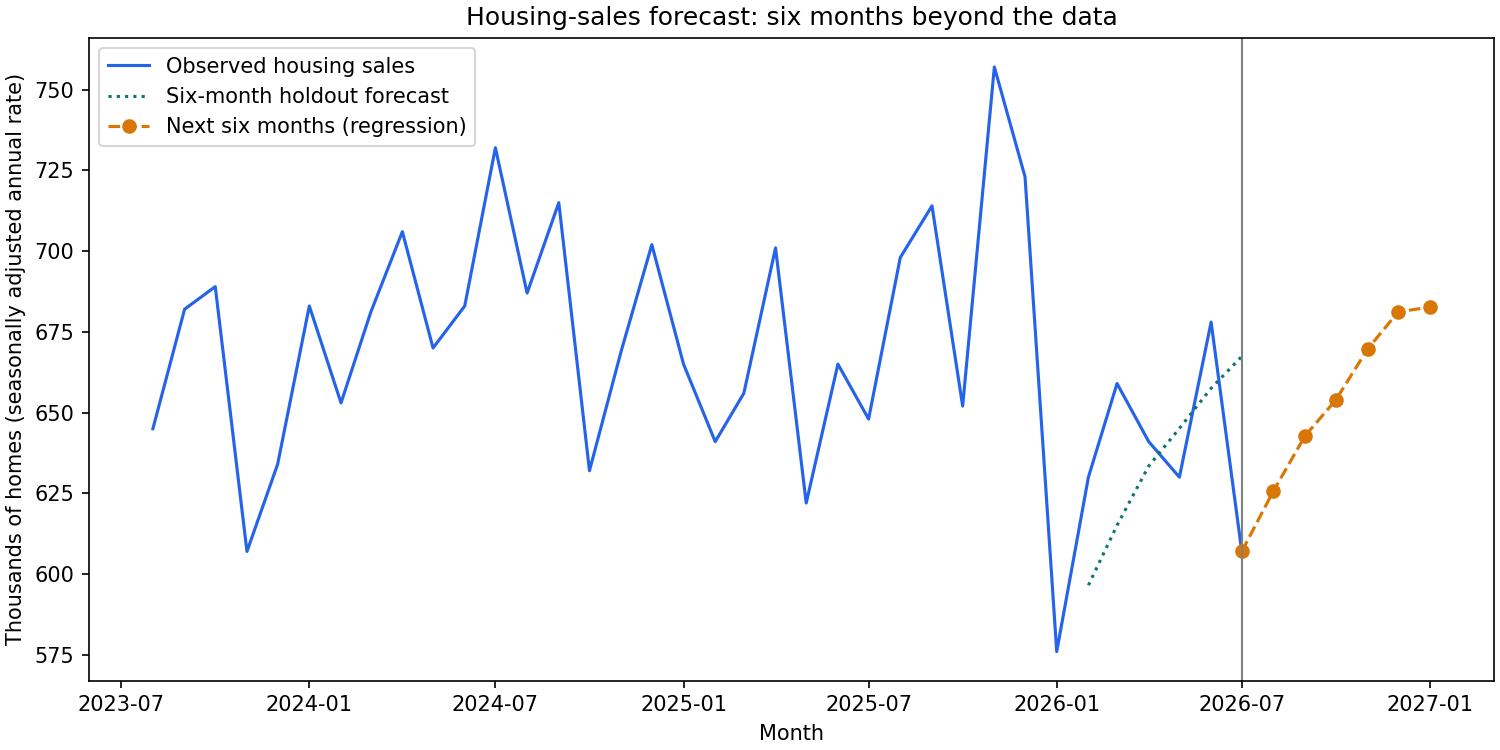

In [16]:
forecast_results = run_forecast(DATA, OUT)
display(Image(filename=str(OUT / "housing_demand_forecast.png")))

## Verify the deliverables
These checks reconcile saved outputs with reported metrics, confirm the source CSVs are available, confirm 100+ records for each required part, check the 0.5 churn threshold and cluster assignments, and verify that the forecast has exactly six future months. They verify execution and consistency, not perfect predictive accuracy.


In [17]:
"""Check actual rubric deliverables and prediction consistency after a run."""
from pathlib import Path
import json
import numpy as np
import pandas as pd


def verify_outputs(data_dir=Path("data"), output_dir=Path("outputs")):
    data_dir, output_dir = Path(data_dir), Path(output_dir)
    checks = []
    required_columns = {
        "kc_house_data.csv": {"id", "sqft_living", "zipcode", "price"},
        "telco_churn.csv": {"customerID", "tenure", "MonthlyCharges", "Churn"},
        "Wholesale customers data.csv": {"Fresh", "Milk", "Grocery", "Frozen"},
        "housing_demand.csv": {"observation_date", "HSN1F"},
    }
    for name, columns in required_columns.items():
        assert columns.issubset(pd.read_csv(data_dir / name, nrows=0).columns)
    checks.append("All four source CSVs are present with the required columns.")
    for name in ["house_metrics.json", "churn_metrics.json", "segmentation_metrics.json"]:
        assert json.loads((output_dir / name).read_text())["rows"] >= 100
    checks.append("Every required part uses at least 100 records.")

    house = json.loads((output_dir / "house_metrics.json").read_text())
    assert house["train_rows"] + house["test_rows"] == house["rows"]
    assert np.isfinite(house["downtown_2000_sqft_prediction"])
    hp = pd.read_csv(output_dir / "house_test_predictions.csv")
    assert len(hp) == house["test_rows"] and np.isfinite(hp).all().all()
    for col, key in [("demo_prediction", "demo"), ("zipcode_prediction", "actual_zipcode")]:
        assert np.isclose(np.abs(hp.actual_price - hp[col]).mean(), house[key]["MAE_USD"])
    checks.append("Housing predictions are finite and saved test errors reproduce the reported MAEs.")

    churn = json.loads((output_dir / "churn_metrics.json").read_text())
    cp = pd.read_csv(output_dir / "churn_test_predictions.csv")
    assert len(cp) == churn["test_rows"] and cp.customerID.is_unique
    assert cp.churn_probability.between(0, 1).all()
    assert np.array_equal((cp.churn_probability >= 0.5).astype(int), cp.predicted_churn)
    assert np.isclose((cp.actual_churn == cp.predicted_churn).mean(), churn["accuracy"])
    assert churn["new_customer_class"] == int(churn["new_customer_probability"] >= 0.5)
    checks.append("Churn probabilities are valid; both held-out and example classes use the 0.5 threshold.")

    segments = json.loads((output_dir / "segmentation_metrics.json").read_text())
    clusters = pd.read_csv(output_dir / "customer_segments.csv")
    assert len(clusters) == segments["rows"] and clusters.customer_row_id.is_unique
    assert clusters.cluster.notna().all() and clusters.cluster.nunique() == segments["selected_k"]
    counts = pd.read_csv(output_dir / "cluster_summary.csv").set_index("cluster").customers
    assert counts.to_dict() == clusters.groupby("cluster").size().to_dict()
    diag = pd.read_csv(output_dir / "cluster_diagnostics.csv")
    assert (np.diff(diag.inertia) < 0).all()
    checks.append("Every customer has one cluster, cluster counts reconcile, and elbow inertia decreases.")

    forecast = pd.read_csv(output_dir / "six_month_forecast.csv", parse_dates=["month"])
    history = pd.read_csv(output_dir / "housing_demand_cleaned.csv", parse_dates=["month"])
    expected = pd.date_range(history.month.max() + pd.offsets.MonthBegin(1), periods=6, freq="MS")
    assert forecast.month.tolist() == expected.tolist()
    values = forecast.forecast_sales_thousands_SAAR
    assert np.isfinite(values).all() and (values >= 0).all()
    backtest = pd.read_csv(output_dir / "forecast_backtest.csv")
    fm = json.loads((output_dir / "forecast_metrics.json").read_text())
    assert np.isclose(np.abs(backtest.actual_sales - backtest.regression_forecast).mean(), fm["backtest_MAE"])
    checks.append("Extra credit forecasts exactly six future months and its backtest error reproduces.")
    for name in ["house_predictions.png", "churn_confusion_matrix.png", "elbow_plot.png",
                 "cluster_profiles.png", "housing_demand_forecast.png"]:
        assert (output_dir / name).read_bytes().startswith(b"\x89PNG\r\n\x1a\n")
    for name in ["part1_explanation.txt", "part2_explanation.txt", "part3_explanation.txt",
                 "extra_credit_explanation.txt"]:
        assert len((output_dir / name).read_text()) > 500
    checks.append("All five plots and four explanation files exist.")
    report = "VERIFICATION PASSED\n\n" + "\n".join(f"PASS: {check}" for check in checks)
    (output_dir / "verification.txt").write_text(report + "\n")
    print(report)
    return checks

In [18]:
checks = verify_outputs(DATA, OUT)

VERIFICATION PASSED

PASS: All four source CSVs are present with the required columns.
PASS: Every required part uses at least 100 records.
PASS: Housing predictions are finite and saved test errors reproduce the reported MAEs.
PASS: Churn probabilities are valid; both held-out and example classes use the 0.5 threshold.
PASS: Every customer has one cluster, cluster counts reconcile, and elbow inertia decreases.
PASS: Extra credit forecasts exactly six future months and its backtest error reproduces.
PASS: All five plots and four explanation files exist.


## Submission checklist

- **Part 1:** CSV source cited; 100+ sales; OneHotEncoder and linear regression; 2,000 sq ft Downtown prediction; printed and explained coefficients; real-ZIP improvement.
- **Part 2:** 100+ customers; StandardScaler and OneHotEncoder; logistic regression; probability and 0.5 threshold; business interpretation.
- **Part 3:** 100+ customers; scaled numerical features; elbow plot and justified K; K-Means; cluster means and tailored strategies; saved assignments.
- **Extra credit:** housing CSV loaded/cleaned; regression; six future months; matplotlib visualization; assumptions, challenges, improvements.
- **Code quality:** readable functions, source comments, fixed random seeds, preprocessing without test leakage, saved outputs and verification.

In [19]:
display(pd.DataFrame({"output_file": sorted(p.name for p in OUT.iterdir() if p.is_file())}))


,output_file
0,churn_coefficients.csv
1,churn_confusion_matrix.png
2,churn_metrics.json
3,churn_test_predictions.csv
4,cluster_diagnostics.csv
5,cluster_profiles.png
6,cluster_summary.csv
7,customer_segments.csv
8,elbow_plot.png
9,extra_credit_explanation.txt
